# Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve the predictive power of machine learning models.

New features can help reveal hidden patterns and relationships in the data. In this section, we create additional features based on customer behavior and financial activity.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("day2_ml_output.csv")

In [2]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,768805383,1,45,1,3,39,5,1,3,12691.0,...,0,0,1,0,0,0,1,0,0,0
1,818770008,1,49,0,5,44,6,1,2,8256.0,...,0,0,0,0,1,0,1,0,0,0
2,713982108,1,51,1,3,36,4,1,0,3418.0,...,0,0,0,1,0,0,1,0,0,0
3,769911858,1,40,0,4,34,3,4,1,3313.0,...,0,0,0,0,1,0,1,0,0,0
4,709106358,1,40,1,3,21,5,1,0,4716.0,...,0,0,1,0,0,0,1,0,0,0


## Feature 1 — Customer Activity Rate

In [3]:
df['Activity_Rate'] = df['Total_Trans_Ct'] / df['Months_on_book']

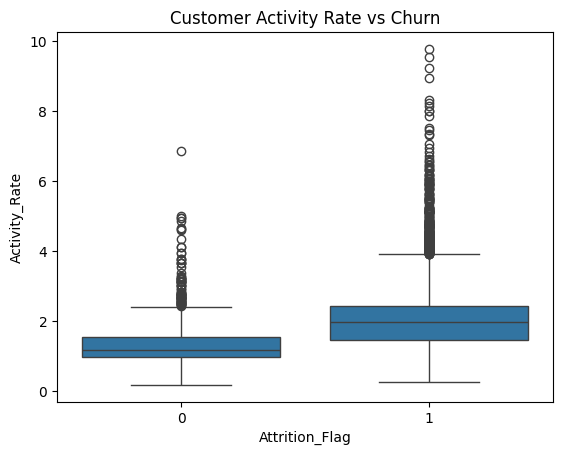

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Attrition_Flag', y='Activity_Rate', data=df)
plt.title("Customer Activity Rate vs Churn")
plt.show()

## Customer Activity Rate vs Churn

The `Activity_Rate` feature measures how frequently a customer uses their credit card and is calculated as:

`Activity_Rate = Total_Trans_Ct / Months_on_book`

The boxplot compares customer activity rates between existing customers and churned customers.

The visualization shows that churned customers have a wider range of activity rates, including several high-activity outliers. This indicates that even customers who frequently use their credit cards may still leave the bank.

## Interpretation

Customer activity rate captures engagement with the bank's credit card services.

Highly active customers may still churn due to:

- dissatisfaction
- better offers from competitors
- financial behavior changes

## Feature 2 — Credit Usage Ratio

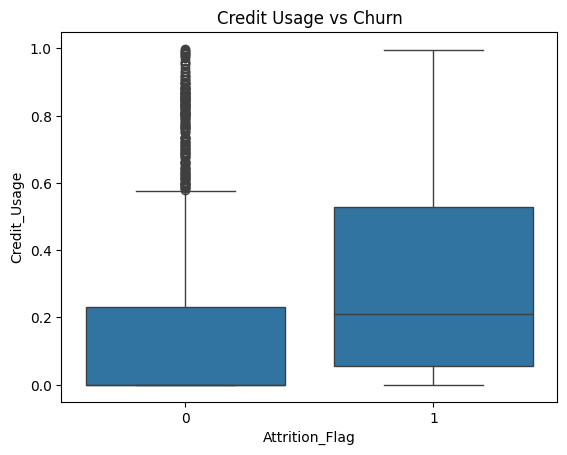

In [5]:
df['Credit_Usage'] = df['Total_Revolving_Bal'] / df['Credit_Limit']
sns.boxplot(x='Attrition_Flag', y='Credit_Usage', data=df)
plt.title("Credit Usage vs Churn")
plt.show()

## Credit Usage Ratio

The `Credit_Usage` feature measures how much of a customer's credit limit is currently being used and is calculated as:

`Credit_Usage = Total_Revolving_Bal / Credit_Limit`

The boxplot compares credit usage between existing customers and churned customers.

The visualization shows that churned customers tend to have higher median credit utilization and a wider distribution compared to existing customers. This suggests that customers who use a larger portion of their credit limit may have a higher likelihood of leaving the bank.

## Interpretation

Credit usage reflects financial behavior and spending habits.

Customers who use a large portion of their credit limit may:

- face financial stress
- have higher debt levels
- be more likely to close accounts or switch banks

## Feature 3 — Transaction Value

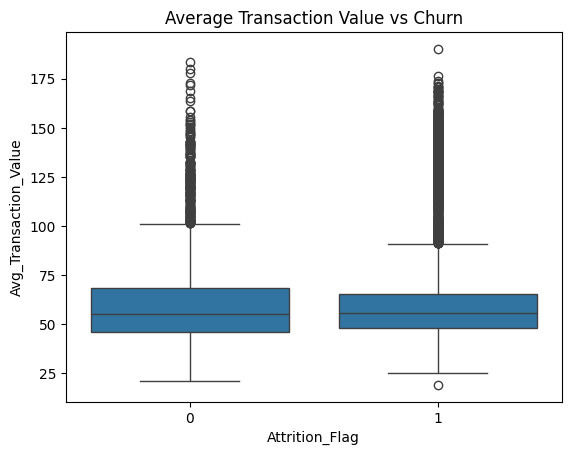

In [7]:
df['Avg_Transaction_Value'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']
sns.boxplot(x='Attrition_Flag', y='Avg_Transaction_Value', data=df)
plt.title("Average Transaction Value vs Churn")
plt.show()

## Average Transaction Value

The `Avg_Transaction_Value` feature represents the average amount spent per transaction and is calculated as:

`Avg_Transaction_Value = Total_Trans_Amt / Total_Trans_Ct`

The boxplot compares average transaction values between existing customers and churned customers.

The visualization shows that both groups have similar median transaction values, suggesting that average spending per transaction alone does not strongly differentiate churned customers from existing ones. However, churned customers display a slightly wider range of transaction values.

## Interpretation

Average transaction value reflects customer spending behavior.

However, based on this visualization, transaction size alone does not strongly indicate churn. It may still contribute to prediction when combined with other behavioral features such as:

- transaction frequency
- credit usage
- inactivity months

# Summary of Engineered Features

Three new features were created during feature engineering:

- `Activity_Rate` – measures how frequently customers use their credit card.
- `Credit_Usage` – measures how much credit limit is utilized.
- `Avg_Transaction_Value` – measures the average spending per transaction.

These engineered features provide additional insights into customer behavior and may improve the predictive performance of machine learning models.

In [8]:
df.to_csv("day3_ml_output.csv", index=False)